# Filtering Data Exploration

Визуализация данных перед обучением. Использует подготовленные `combined_labels.jsonl`, `splits.json`, `candidates_topic_filtered.jsonl`, `labels.jsonl`, `labels_llm.jsonl`.

Запусти ячейки последовательно (Shift+Enter).

In [10]:
import json
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('data')
ROOT = Path(r'C:\Users\70133\VS_Code_Projects\jarvis-core\notebooks\webui')

def load_jsonl(p):
    with open(p, encoding='utf-8') as f:
        return [json.loads(l) for l in f if l.strip()]

combined = load_jsonl(DATA_DIR / 'combined_labels.jsonl')
with open(DATA_DIR / 'splits.json', encoding='utf-8') as f:
    splits_data = json.load(f)
splits = splits_data['splits']
topic_map = splits_data['page_topic']

candidates = load_jsonl(ROOT / 'annotator' / 'candidates_topic_filtered.jsonl')
human = load_jsonl(ROOT / 'annotator' / 'output' / 'labels.jsonl')
llm = load_jsonl(ROOT / 'annotator' / 'output' / 'labels_llm.jsonl')

cand_idx = {f"{c['page_id']}::{c['node_id']}": c for c in candidates}

print(f'Combined labels: {len(combined)}')
print(f'Candidates total: {len(candidates)}')
print(f'Human labels: {len(human)}')
print(f'LLM labels: {len(llm)}')
print(f'Pages in dataset: {len(set(r["page_id"] for r in combined))}')
print(f'Splits: ' + ', '.join(f"{s}={sum(1 for v in splits.values() if v == s)}" for s in ('train', 'val', 'test')))

Combined labels: 5604
Candidates total: 6220
Human labels: 1534
LLM labels: 5609
Pages in dataset: 352
Splits: train=278, val=32, test=42


## 1. Label distribution (combined: human + LLM)

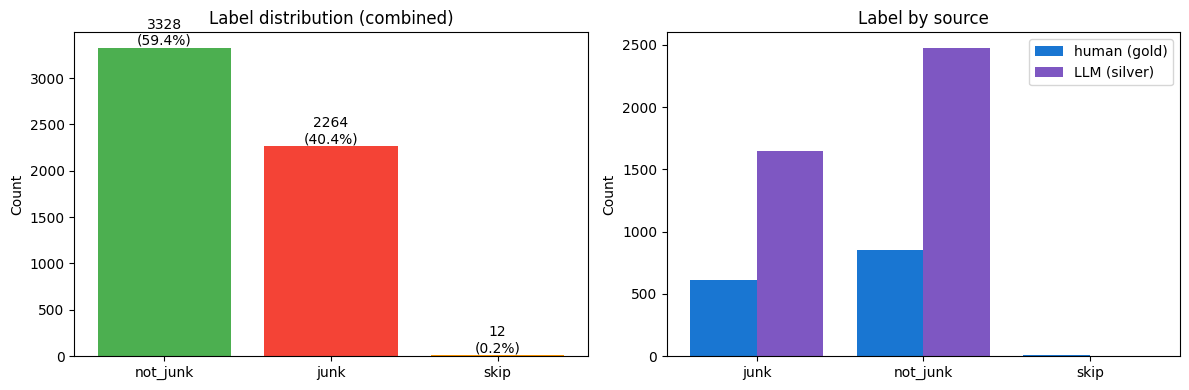

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels_count = Counter(r['label'] for r in combined)
axes[0].bar(labels_count.keys(), labels_count.values(), color=['#4caf50', '#f44336', '#ff9800'])
axes[0].set_title('Label distribution (combined)')
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(labels_count.items()):
    axes[0].text(i, v, f'{v}\n({100*v/len(combined):.1f}%)', ha='center', va='bottom')

source_count = Counter((r['label'], r['label_source']) for r in combined)
labels_set = sorted(set(k[0] for k in source_count))
humans = [source_count.get((l, 'human'), 0) for l in labels_set]
llms = [source_count.get((l, 'llm'), 0) for l in labels_set]
x = np.arange(len(labels_set))
axes[1].bar(x - 0.2, humans, 0.4, label='human (gold)', color='#1976d2')
axes[1].bar(x + 0.2, llms, 0.4, label='LLM (silver)', color='#7e57c2')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_set)
axes[1].set_title('Label by source')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Sub-label distribution (junk only) by source

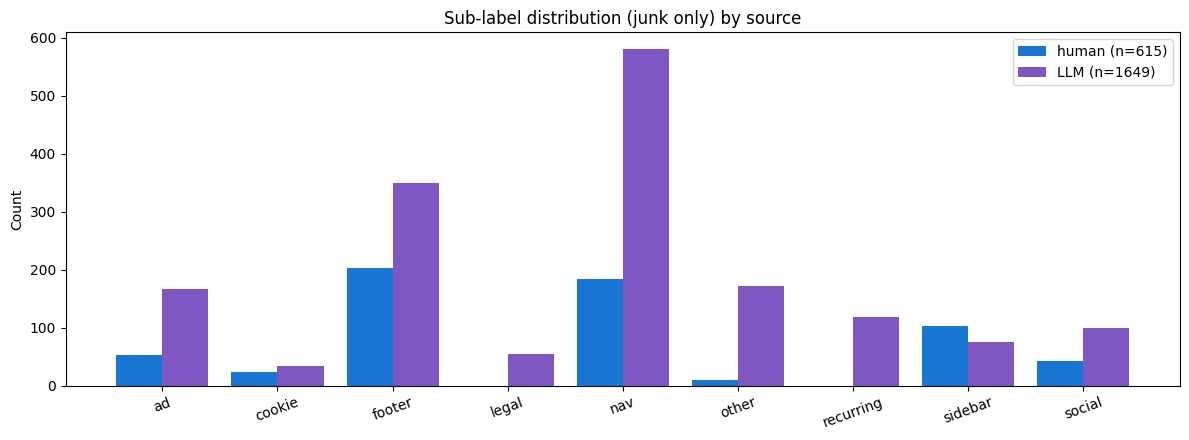

Note: human уверенно использует footer/nav/sidebar, LLM больше использует recurring/legal/other


In [12]:
junk_human = [r for r in combined if r['label'] == 'junk' and r['label_source'] == 'human']
junk_llm = [r for r in combined if r['label'] == 'junk' and r['label_source'] == 'llm']
sl_human = Counter(r.get('sub_label', '') for r in junk_human)
sl_llm = Counter(r.get('sub_label', '') for r in junk_llm)

all_sl = sorted(set(sl_human) | set(sl_llm))
h_vals = [sl_human.get(s, 0) for s in all_sl]
l_vals = [sl_llm.get(s, 0) for s in all_sl]

x = np.arange(len(all_sl))
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(x - 0.2, h_vals, 0.4, label=f'human (n={len(junk_human)})', color='#1976d2')
ax.bar(x + 0.2, l_vals, 0.4, label=f'LLM (n={len(junk_llm)})', color='#7e57c2')
ax.set_xticks(x)
ax.set_xticklabels(all_sl, rotation=20)
ax.set_title('Sub-label distribution (junk only) by source')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print('Note: human уверенно использует footer/nav/sidebar, LLM больше использует recurring/legal/other')

## 3. Splits — sizes & balance

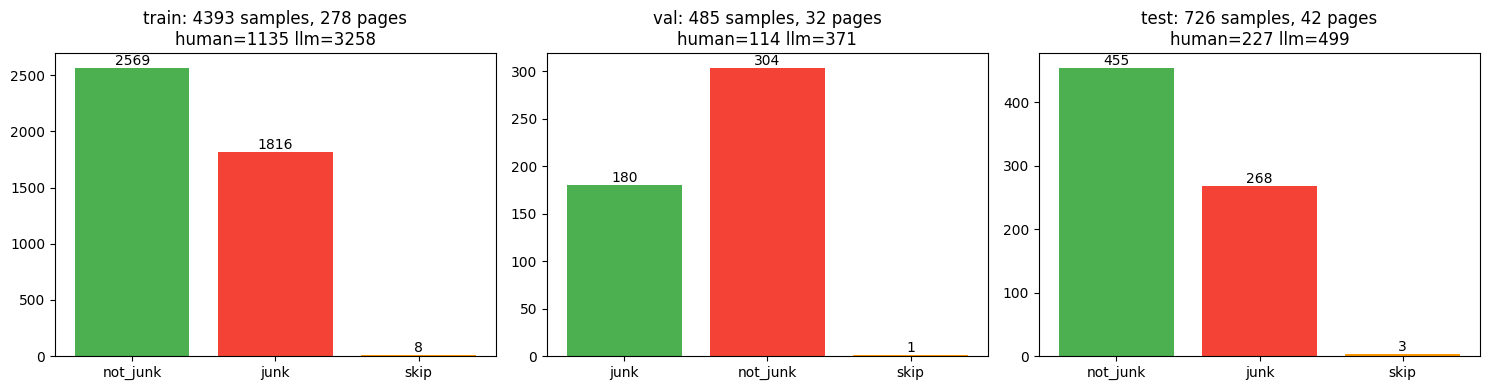

In [13]:
by_split = defaultdict(list)
for r in combined:
    by_split[splits.get(r['page_id'])].append(r)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, sp in zip(axes, ['train', 'val', 'test']):
    rows = by_split[sp]
    cnt = Counter(r['label'] for r in rows)
    src = Counter(r['label_source'] for r in rows)
    ax.bar(cnt.keys(), cnt.values(), color=['#4caf50', '#f44336', '#ff9800'])
    n_pages = len(set(r['page_id'] for r in rows))
    ax.set_title(f'{sp}: {len(rows)} samples, {n_pages} pages\nhuman={src["human"]} llm={src["llm"]}')
    for i, (k, v) in enumerate(cnt.items()):
        ax.text(i, v, f'{v}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 4. Per-topic split breakdown

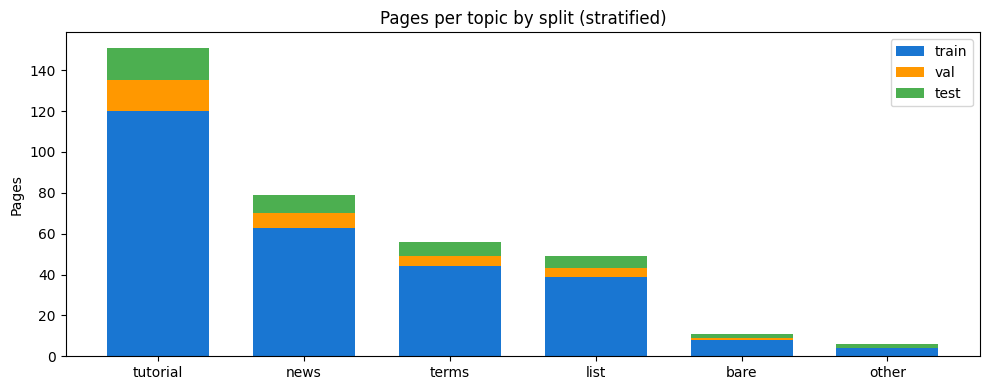

In [14]:
topics = ['tutorial', 'news', 'terms', 'list', 'bare', 'other']
topic_split = defaultdict(lambda: Counter())
for pid, sp in splits.items():
    t = topic_map.get(pid, 'unknown')
    topic_split[t][sp] += 1

x = np.arange(len(topics))
tr = [topic_split[t]['train'] for t in topics]
va = [topic_split[t]['val'] for t in topics]
te = [topic_split[t]['test'] for t in topics]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x, tr, 0.7, label='train', color='#1976d2')
ax.bar(x, va, 0.7, bottom=tr, label='val', color='#ff9800')
ax.bar(x, te, 0.7, bottom=[a+b for a, b in zip(tr, va)], label='test', color='#4caf50')
ax.set_xticks(x)
ax.set_xticklabels(topics)
ax.set_ylabel('Pages')
ax.set_title('Pages per topic by split (stratified)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Numeric feature distributions (raw, junk vs not_junk)

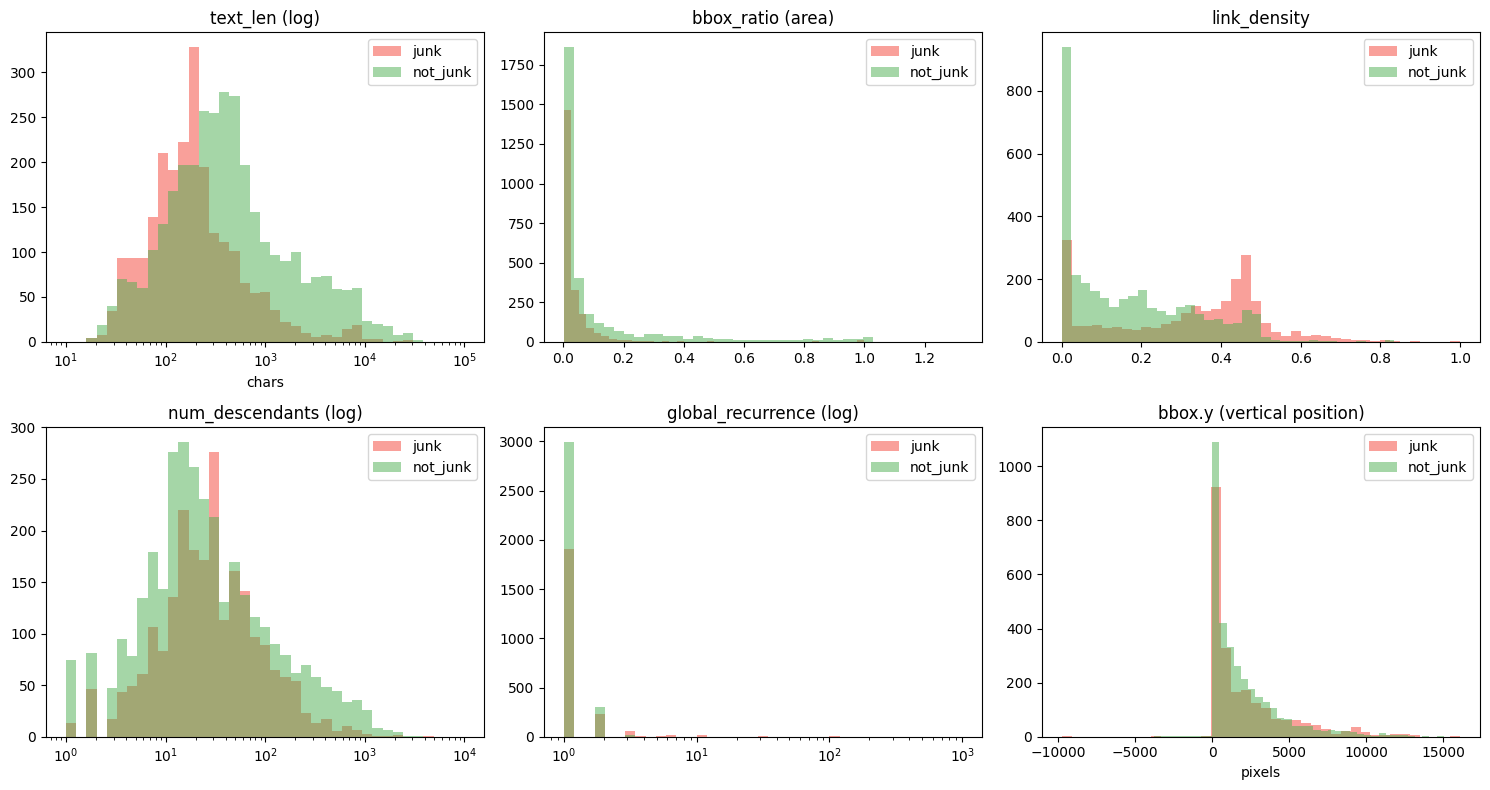

In [15]:
junk_cands = [cand_idx[f"{r['page_id']}::{r['node_id']}"] for r in combined
              if r['label'] == 'junk' and f"{r['page_id']}::{r['node_id']}" in cand_idx]
nj_cands = [cand_idx[f"{r['page_id']}::{r['node_id']}"] for r in combined
            if r['label'] == 'not_junk' and f"{r['page_id']}::{r['node_id']}" in cand_idx]

def feat(cands, key):
    return [c.get(key) or 0 for c in cands]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

ax = axes[0][0]
bins = np.logspace(1, 5, 40)
ax.hist(feat(junk_cands, 'text_len'), bins=bins, alpha=0.5, label='junk', color='#f44336')
ax.hist(feat(nj_cands, 'text_len'), bins=bins, alpha=0.5, label='not_junk', color='#4caf50')
ax.set_xscale('log'); ax.set_title('text_len (log)'); ax.legend(); ax.set_xlabel('chars')

ax = axes[0][1]
ax.hist(feat(junk_cands, 'bbox_ratio'), bins=40, alpha=0.5, label='junk', color='#f44336')
ax.hist(feat(nj_cands, 'bbox_ratio'), bins=40, alpha=0.5, label='not_junk', color='#4caf50')
ax.set_title('bbox_ratio (area)'); ax.legend()

ax = axes[0][2]
ax.hist(feat(junk_cands, 'link_density'), bins=40, alpha=0.5, label='junk', color='#f44336')
ax.hist(feat(nj_cands, 'link_density'), bins=40, alpha=0.5, label='not_junk', color='#4caf50')
ax.set_title('link_density'); ax.legend()

ax = axes[1][0]
bins = np.logspace(0, 4, 40)
ax.hist([max(1, x) for x in feat(junk_cands, 'num_descendants')], bins=bins, alpha=0.5, label='junk', color='#f44336')
ax.hist([max(1, x) for x in feat(nj_cands, 'num_descendants')], bins=bins, alpha=0.5, label='not_junk', color='#4caf50')
ax.set_xscale('log'); ax.set_title('num_descendants (log)'); ax.legend()

ax = axes[1][1]
bins = np.logspace(0, 3, 40)
ax.hist([max(1, x) for x in feat(junk_cands, 'global_recurrence_count')], bins=bins, alpha=0.5, label='junk', color='#f44336')
ax.hist([max(1, x) for x in feat(nj_cands, 'global_recurrence_count')], bins=bins, alpha=0.5, label='not_junk', color='#4caf50')
ax.set_xscale('log'); ax.set_title('global_recurrence (log)'); ax.legend()

ax = axes[1][2]
junk_y = [(c.get('bbox') or {}).get('y', 0) for c in junk_cands]
nj_y = [(c.get('bbox') or {}).get('y', 0) for c in nj_cands]
ax.hist(junk_y, bins=40, alpha=0.5, label='junk', color='#f44336')
ax.hist(nj_y, bins=40, alpha=0.5, label='not_junk', color='#4caf50')
ax.set_title('bbox.y (vertical position)'); ax.legend(); ax.set_xlabel('pixels')

plt.tight_layout()
plt.show()

## 6. Role distribution by class

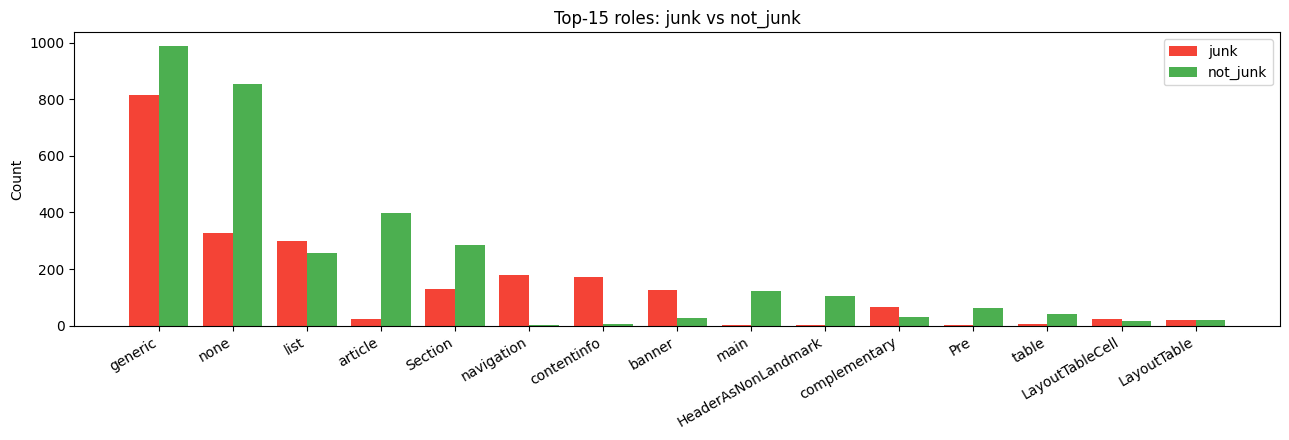

Junk-rate per role (среди labeled):
  generic                  :  816 junk / 1803 total =  45.3% junk
  none                     :  328 junk / 1183 total =  27.7% junk
  list                     :  298 junk /  555 total =  53.7% junk
  article                  :   25 junk /  422 total =   5.9% junk
  Section                  :  131 junk /  415 total =  31.6% junk
  navigation               :  179 junk /  183 total =  97.8% junk
  contentinfo              :  173 junk /  180 total =  96.1% junk
  banner                   :  127 junk /  153 total =  83.0% junk
  main                     :    3 junk /  124 total =   2.4% junk
  HeaderAsNonLandmark      :    3 junk /  107 total =   2.8% junk
  complementary            :   65 junk /   96 total =  67.7% junk
  Pre                      :    2 junk /   65 total =   3.1% junk
  table                    :    5 junk /   46 total =  10.9% junk
  LayoutTableCell          :   25 junk /   41 total =  61.0% junk
  LayoutTable              :   21 junk /

In [16]:
junk_roles = Counter(c.get('role', '') for c in junk_cands)
nj_roles = Counter(c.get('role', '') for c in nj_cands)
all_roles = sorted(set(junk_roles) | set(nj_roles), key=lambda r: -(junk_roles[r] + nj_roles[r]))[:15]

x = np.arange(len(all_roles))
j_vals = [junk_roles[r] for r in all_roles]
n_vals = [nj_roles[r] for r in all_roles]

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(x - 0.2, j_vals, 0.4, label='junk', color='#f44336')
ax.bar(x + 0.2, n_vals, 0.4, label='not_junk', color='#4caf50')
ax.set_xticks(x)
ax.set_xticklabels(all_roles, rotation=30, ha='right')
ax.set_title('Top-15 roles: junk vs not_junk')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print('Junk-rate per role (среди labeled):')
for r in all_roles:
    total = junk_roles[r] + nj_roles[r]
    rate = junk_roles[r] / total if total else 0
    print(f'  {r:25s}: {junk_roles[r]:>4d} junk / {total:>4d} total = {rate*100:>5.1f}% junk')

## 7. Human vs LLM agreement on overlap

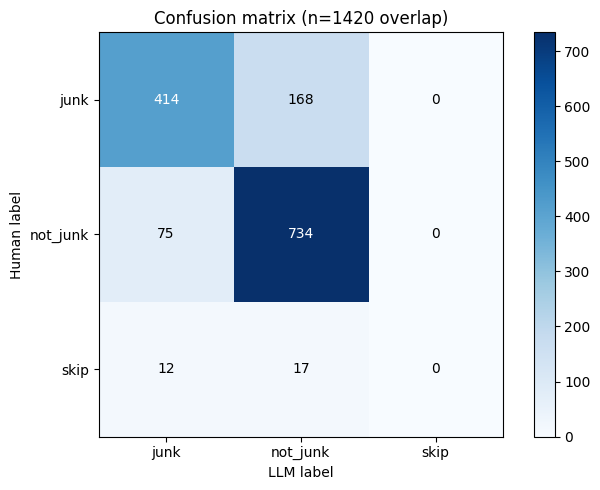

3-way agreement: 0.808 (1148/1420)


In [17]:
h_idx = {f"{r['page_id']}::{r['node_id']}": r for r in human}
l_idx = {f"{r['page_id']}::{r['node_id']}": r for r in llm}
common = set(h_idx) & set(l_idx)

cm = defaultdict(int)
for k in common:
    cm[(h_idx[k]['label'], l_idx[k]['label'])] += 1

labels_set = ['junk', 'not_junk', 'skip']
matrix = np.array([[cm.get((h, l), 0) for l in labels_set] for h in labels_set])

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(matrix, cmap='Blues')
ax.set_xticks(range(len(labels_set))); ax.set_xticklabels(labels_set)
ax.set_yticks(range(len(labels_set))); ax.set_yticklabels(labels_set)
ax.set_xlabel('LLM label'); ax.set_ylabel('Human label')
ax.set_title(f'Confusion matrix (n={len(common)} overlap)')
for i in range(len(labels_set)):
    for j in range(len(labels_set)):
        ax.text(j, i, str(matrix[i, j]), ha='center', va='center',
                color='white' if matrix[i, j] > matrix.max()/2 else 'black')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

diag = sum(matrix[i, i] for i in range(len(labels_set)))
print(f'3-way agreement: {diag/len(common):.3f} ({diag}/{len(common)})')

## 8. Per-page candidate count distribution

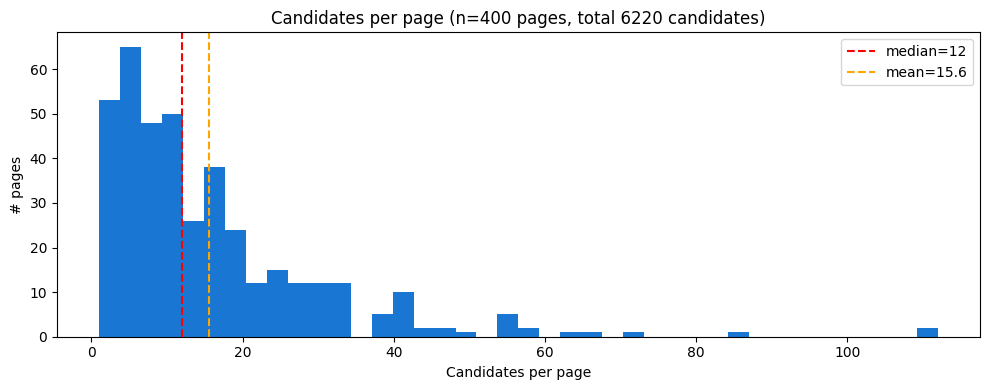

min/max: 1/112
pages with <3 candidates (low-quality): 35


In [18]:
per_page = Counter(c['page_id'] for c in candidates)
counts = list(per_page.values())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(counts, bins=40, color='#1976d2')
ax.axvline(np.median(counts), color='red', linestyle='--', label=f'median={np.median(counts):.0f}')
ax.axvline(np.mean(counts), color='orange', linestyle='--', label=f'mean={np.mean(counts):.1f}')
ax.set_xlabel('Candidates per page'); ax.set_ylabel('# pages')
ax.set_title(f'Candidates per page (n={len(per_page)} pages, total {sum(counts)} candidates)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'min/max: {min(counts)}/{max(counts)}')
print(f'pages with <3 candidates (low-quality): {sum(1 for c in counts if c < 3)}')

---
# 9. Actual feature matrices (то что подаётся в модель)

Загружаем `features_*.npz`, `word_tfidf_*.npz`, `char_tfidf_*.npz` — это финальные матрицы которые идут в `model.fit()`.

In [19]:
from scipy.sparse import load_npz

feat_train = np.load(DATA_DIR / 'features_train.npz')
word_tfidf_train = load_npz(DATA_DIR / 'word_tfidf_train.npz')
char_tfidf_train = load_npz(DATA_DIR / 'char_tfidf_train.npz')
with open(DATA_DIR / 'labels_train.json', encoding='utf-8') as f:
    labels_train = json.load(f)
with open(DATA_DIR / 'feature_meta.json', encoding='utf-8') as f:
    fmeta = json.load(f)

y_train = np.array([1 if l['label'] == 'junk' else 0 for l in labels_train])

print(f'Train samples: {len(labels_train)}')
print(f'Geometric: shape={feat_train["geometric"].shape}, columns={fmeta["geometric"]}')
print(f'Structural: shape={feat_train["structural"].shape}, columns={fmeta["structural"]}')
print(f'Recurrence: shape={feat_train["recurrence"].shape}, columns={fmeta["recurrence"]}')
print(f'Role one-hot: shape={feat_train["role_onehot"].shape}')
print(f'Word TF-IDF: shape={word_tfidf_train.shape}, density={word_tfidf_train.nnz / (word_tfidf_train.shape[0]*word_tfidf_train.shape[1]):.4f}')
print(f'Char TF-IDF: shape={char_tfidf_train.shape}, density={char_tfidf_train.nnz / (char_tfidf_train.shape[0]*char_tfidf_train.shape[1]):.4f}')
total_feat = feat_train['geometric'].shape[1] + feat_train['structural'].shape[1] + feat_train['recurrence'].shape[1] + feat_train['role_onehot'].shape[1] + word_tfidf_train.shape[1] + char_tfidf_train.shape[1]
print(f'\nTotal features per sample: {total_feat}')
print(f'Class balance: junk={y_train.sum()}, not_junk={(y_train==0).sum()} ({100*y_train.mean():.1f}% junk)')

Train samples: 4393
Geometric: shape=(4393, 6), columns=['bbox_x_norm', 'bbox_y_norm', 'bbox_w_norm', 'bbox_h_norm', 'bbox_area_log', 'bbox_ratio']
Structural: shape=(4393, 6), columns=['text_len_log', 'own_text_len_log', 'num_descendants_log', 'num_children_log', 'link_density', 'depth']
Recurrence: shape=(4393, 3), columns=['grec_count_log', 'grec_ratio', 'rec_count_log']
Role one-hot: shape=(4393, 16)
Word TF-IDF: shape=(4393, 10000), density=0.0056
Char TF-IDF: shape=(4393, 10000), density=0.0418

Total features per sample: 20031
Class balance: junk=1816, not_junk=2577 (41.3% junk)


## 10. Distributions of TRANSFORMED numeric features (junk vs not_junk)

Это распределение значений ПОСЛЕ log/normalize — то что реально видит модель.

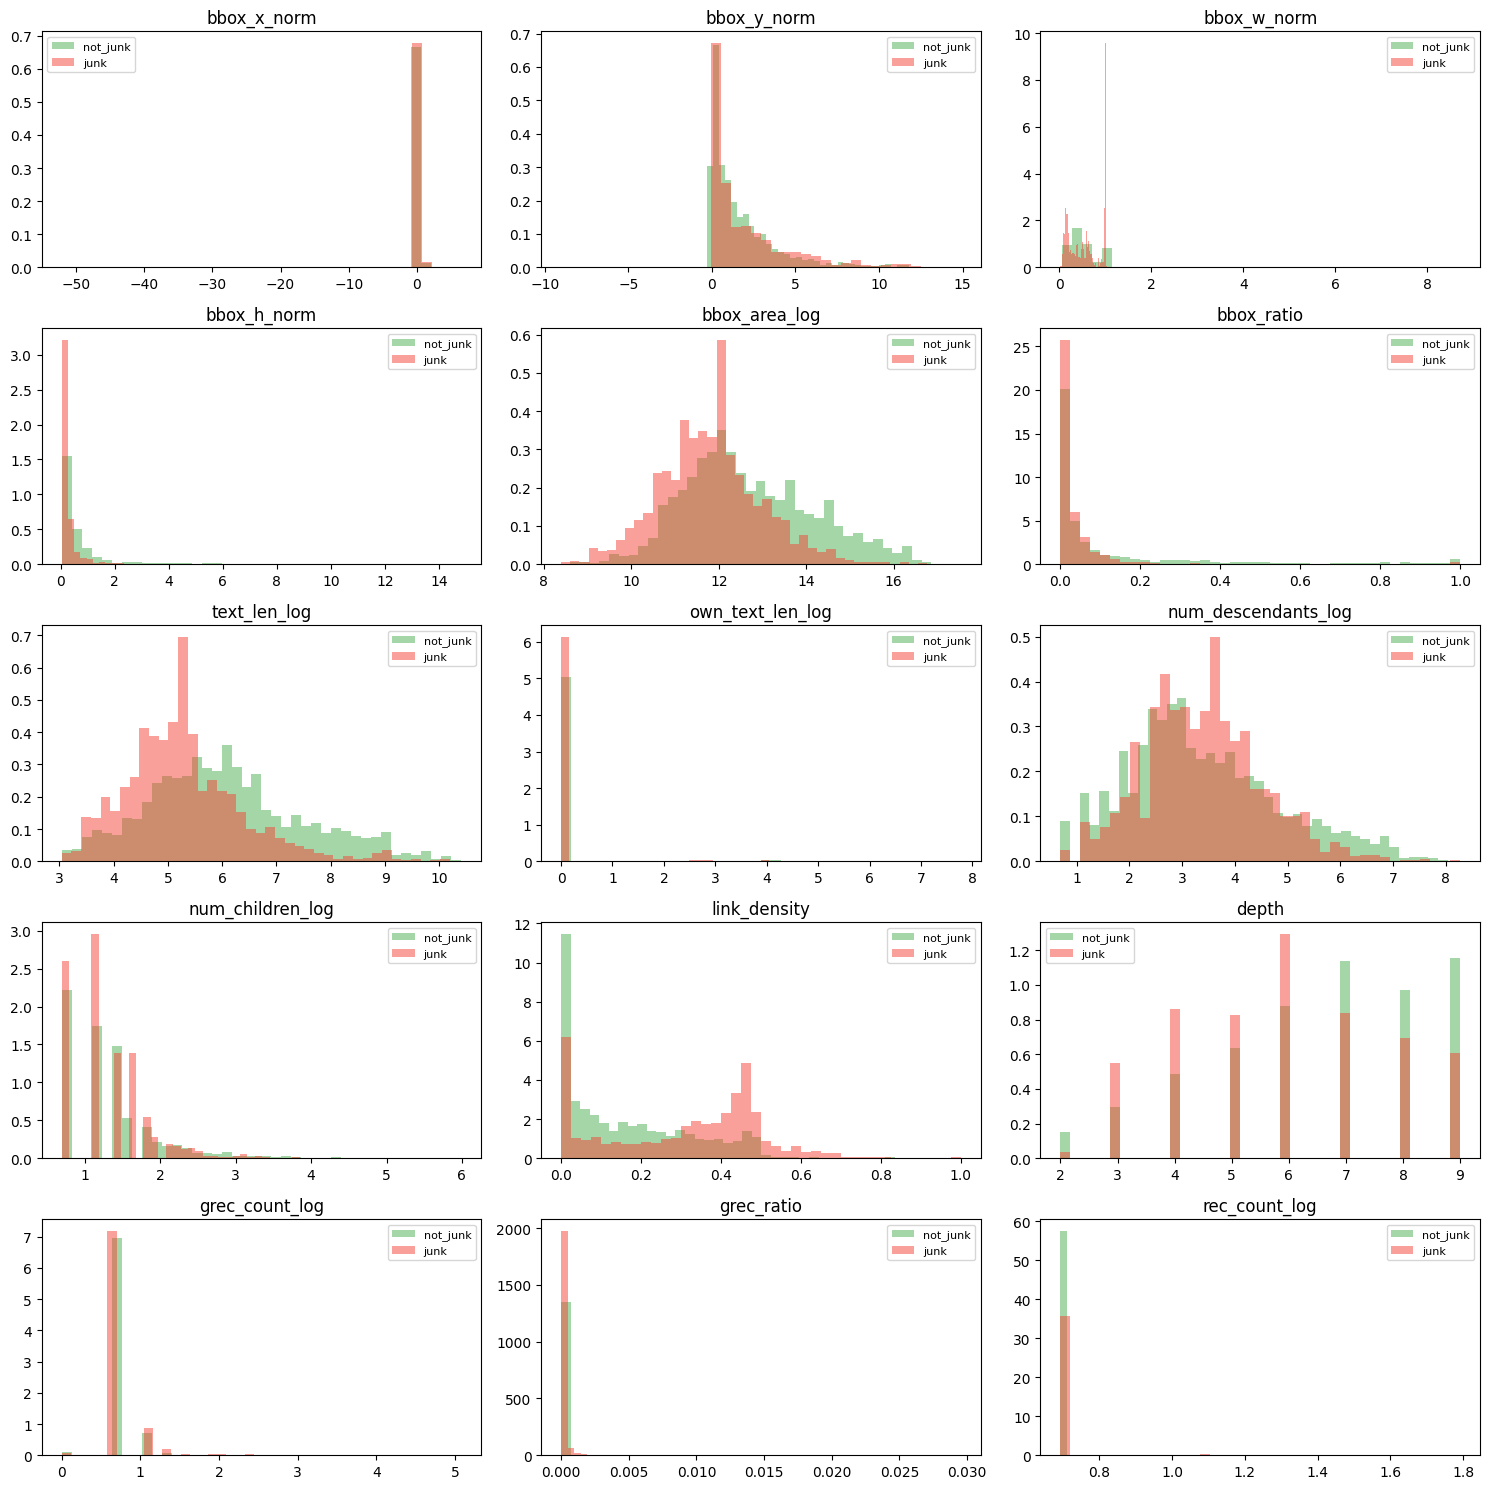

In [20]:
all_columns = []
all_columns.extend((c, feat_train['geometric'][:, i]) for i, c in enumerate(fmeta['geometric']))
all_columns.extend((c, feat_train['structural'][:, i]) for i, c in enumerate(fmeta['structural']))
all_columns.extend((c, feat_train['recurrence'][:, i]) for i, c in enumerate(fmeta['recurrence']))

n = len(all_columns)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows))
axes = axes.flatten()
i = 0
for i, (name, vals) in enumerate(all_columns):
    ax = axes[i]
    junk_v = vals[y_train == 1]
    nj_v = vals[y_train == 0]
    ax.hist(nj_v, bins=40, alpha=0.5, label='not_junk', color='#4caf50', density=True)
    ax.hist(junk_v, bins=40, alpha=0.5, label='junk', color='#f44336', density=True)
    ax.set_title(name)
    ax.legend(fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

## 11. Role one-hot prevalence (по классам)

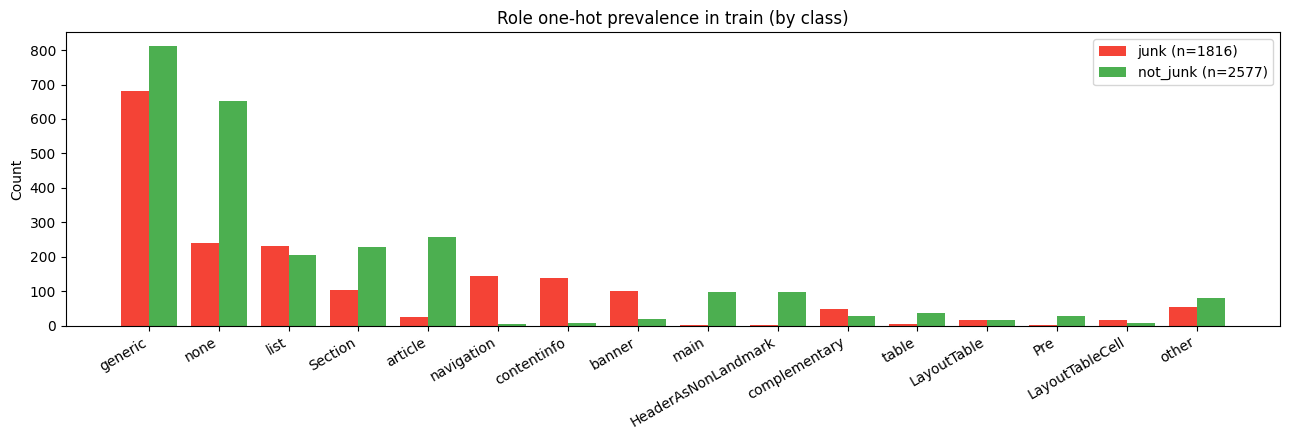

Junk-rate per role в train data (что видит модель):
  role=generic                  :  681 junk / 1492 total =  45.6% junk
  role=none                     :  241 junk /  892 total =  27.0% junk
  role=list                     :  232 junk /  437 total =  53.1% junk
  role=Section                  :  103 junk /  331 total =  31.1% junk
  role=article                  :   25 junk /  283 total =   8.8% junk
  role=navigation               :  144 junk /  148 total =  97.3% junk
  role=contentinfo              :  139 junk /  146 total =  95.2% junk
  role=banner                   :  102 junk /  121 total =  84.3% junk
  role=main                     :    3 junk /  100 total =   3.0% junk
  role=HeaderAsNonLandmark      :    3 junk /  100 total =   3.0% junk
  role=complementary            :   48 junk /   76 total =  63.2% junk
  role=table                    :    5 junk /   43 total =  11.6% junk
  role=LayoutTable              :   17 junk /   35 total =  48.6% junk
  role=Pre               

In [21]:
role_cols = fmeta['role_one_hot']
role_mat = feat_train['role_onehot']

junk_role_count = role_mat[y_train == 1].sum(axis=0)
nj_role_count = role_mat[y_train == 0].sum(axis=0)

x = np.arange(len(role_cols))
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(x - 0.2, junk_role_count, 0.4, label=f'junk (n={int(y_train.sum())})', color='#f44336')
ax.bar(x + 0.2, nj_role_count, 0.4, label=f'not_junk (n={int((y_train==0).sum())})', color='#4caf50')
ax.set_xticks(x)
ax.set_xticklabels([r.replace('role=', '') for r in role_cols], rotation=30, ha='right')
ax.set_title('Role one-hot prevalence in train (by class)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print('Junk-rate per role в train data (что видит модель):')
for i, r in enumerate(role_cols):
    total = junk_role_count[i] + nj_role_count[i]
    rate = junk_role_count[i] / total if total else 0
    print(f'  {r:30s}: {int(junk_role_count[i]):>4d} junk / {int(total):>4d} total = {rate*100:>5.1f}% junk')

## 12. Sample data table (5 примеров каждого класса)

In [22]:
import pandas as pd

all_feat_cols = fmeta['geometric'] + fmeta['structural'] + fmeta['recurrence']
all_feat_data = np.hstack([feat_train['geometric'], feat_train['structural'], feat_train['recurrence']])
df = pd.DataFrame(all_feat_data, columns=all_feat_cols)
df.insert(0, 'label', ['junk' if y == 1 else 'not_junk' for y in y_train])
df.insert(1, 'role', [l['role'] for l in labels_train])
df.insert(2, 'sub_label', [l.get('sub_label', '') for l in labels_train])
df.insert(3, 'source', [l.get('label_source', '') for l in labels_train])

print('=== 5 random JUNK samples ===')
junk_df = df[df['label'] == 'junk'].sample(5, random_state=42)
for c in junk_df.select_dtypes(include='float').columns:
    junk_df[c] = junk_df[c].round(3)
print(junk_df.to_string())

print('\n=== 5 random NOT_JUNK samples ===')
nj_df = df[df['label'] == 'not_junk'].sample(5, random_state=42)
for c in nj_df.select_dtypes(include='float').columns:
    nj_df[c] = nj_df[c].round(3)
print(nj_df.to_string())

=== 5 random JUNK samples ===
     label     role  sub_label source  bbox_x_norm  bbox_y_norm  bbox_w_norm  bbox_h_norm  bbox_area_log  bbox_ratio  text_len_log  own_text_len_log  num_descendants_log  num_children_log  link_density  depth  grec_count_log  grec_ratio  rec_count_log
3385  junk     list     footer    llm        0.664        2.021        0.125        0.062          9.685       0.003         5.403               0.0                2.944             1.792         0.543    8.0           1.099         0.0          0.693
1523  junk  generic         ad    llm        0.000        0.028        1.000        0.306         13.359       0.080         4.718               0.0                2.197             1.386         0.288    5.0           0.693         0.0          0.693
374   junk     none    sidebar  human        0.008        0.865        0.108        0.168         10.536       0.008         5.347               0.0                3.401             1.099         0.359    8.0      

## 13. Summary statistics per feature

In [23]:
summary = df.groupby('label')[all_feat_cols].agg(['mean', 'std', 'min', 'max']).round(3)
print(summary.T)

label                          junk   not_junk
bbox_x_norm         mean   0.097000   0.228000
                    std    2.478000   1.106000
                    min  -52.083000 -51.905998
                    max    5.005000   6.505000
bbox_y_norm         mean   1.921000   1.703000
                    std    2.517000   2.120000
                    min   -9.031000  -0.296000
                    max   14.887000  13.913000
bbox_w_norm         mean   0.571000   0.529000
                    std    0.348000   0.386000
                    min    0.022000   0.051000
                    max    1.067000   8.719000
bbox_h_norm         mean   0.263000   0.789000
                    std    0.481000   1.432000
                    min    0.037000   0.037000
                    max    9.278000  14.822000
bbox_area_log       mean  11.802000  12.704000
                    std    1.153000   1.487000
                    min    8.394000   8.601000
                    max   16.761999  17.528999
bbox_ratio   

## 14. TF-IDF vocab — top word/char n-grams

In [24]:
import pickle
with open(DATA_DIR / 'tfidf_vectorizers.pkl', 'rb') as f:
    vec = pickle.load(f)
word_vec = vec['word']
char_vec = vec['char']

word_df_counts = (word_tfidf_train > 0).sum(axis=0).A1
word_vocab_inv = {i: w for w, i in word_vec.vocabulary_.items()}
top_words = sorted(range(len(word_df_counts)), key=lambda i: -word_df_counts[i])[:30]
print('Top-30 word n-grams (by document frequency):')
for i in top_words:
    print(f'  {word_vocab_inv[i]:30s}: {int(word_df_counts[i]):>4d} docs')

print()
char_df_counts = (char_tfidf_train > 0).sum(axis=0).A1
char_vocab_inv = {i: w for w, i in char_vec.vocabulary_.items()}
top_chars = sorted(range(len(char_df_counts)), key=lambda i: -char_df_counts[i])[:20]
print('Top-20 char n-grams (by document frequency):')
for i in top_chars:
    print(f'  {repr(char_vocab_inv[i]):20s}: {int(char_df_counts[i]):>4d} docs')

Top-30 word n-grams (by document frequency):
  and                           : 1634 docs
  the                           : 1598 docs
  to                            : 1460 docs
  of                            : 1364 docs
  for                           : 1159 docs
  in                            : 1146 docs
  by                            :  921 docs
  on                            :  921 docs
  is                            :  883 docs
  with                          :  854 docs
  our                           :  831 docs
  2022                          :  804 docs
  your                          :  770 docs
  from                          :  769 docs
  you                           :  758 docs
  about                         :  745 docs
  more                          :  658 docs
  this                          :  619 docs
  are                           :  607 docs
  all                           :  587 docs
  that                          :  587 docs
  an                           

## 15. TF-IDF — какие word n-grams сильнее всего различают junk vs not_junk

Топ положительных diff = индикаторы junk, топ отрицательных = индикаторы content.

In [25]:
junk_mask = y_train == 1
junk_word_means = np.asarray(word_tfidf_train[junk_mask].mean(axis=0)).flatten()
nj_word_means = np.asarray(word_tfidf_train[~junk_mask].mean(axis=0)).flatten()
diff = junk_word_means - nj_word_means

top_junk_idx = np.argsort(diff)[::-1][:25]
top_content_idx = np.argsort(diff)[:25]

print('Top-25 word n-grams indicating JUNK:')
for i in top_junk_idx:
    print(f'  {word_vocab_inv[i]:30s}: diff={diff[i]:+.4f}  (junk_avg={junk_word_means[i]:.4f}, content_avg={nj_word_means[i]:.4f})')

print()
print('Top-25 word n-grams indicating CONTENT:')
for i in top_content_idx:
    print(f'  {word_vocab_inv[i]:30s}: diff={diff[i]:+.4f}  (junk_avg={junk_word_means[i]:.4f}, content_avg={nj_word_means[i]:.4f})')

Top-25 word n-grams indicating JUNK:
  contact                       : diff=+0.0185  (junk_avg=0.0229, content_avg=0.0044)
  home                          : diff=+0.0163  (junk_avg=0.0191, content_avg=0.0028)
  lastmod                       : diff=+0.0159  (junk_avg=0.0159, content_avg=0.0000)
  loc                           : diff=+0.0159  (junk_avg=0.0159, content_avg=0.0000)
  changefreq                    : diff=+0.0159  (junk_avg=0.0159, content_avg=0.0000)
  priority                      : diff=+0.0155  (junk_avg=0.0156, content_avg=0.0001)
  twitter                       : diff=+0.0147  (junk_avg=0.0173, content_avg=0.0026)
  url                           : diff=+0.0146  (junk_avg=0.0157, content_avg=0.0011)
  privacy                       : diff=+0.0136  (junk_avg=0.0182, content_avg=0.0046)
  blog                          : diff=+0.0133  (junk_avg=0.0165, content_avg=0.0032)
  news                          : diff=+0.0132  (junk_avg=0.0164, content_avg=0.0032)
  about          